# Dimensionality Reduction with PCA

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

### Table of Contents:


1. [Introduction](#intro)
2. [Section 1 — The Curse of Dimensionality](#section1)
3. [Section 2 — PCA](#section2)
4. [Section 3 — Hands-on Lap](#section3)
5. [References](#refs)

### Learning Objectives Of This Notebook
- Use t-SNE to visualize high-dimensional data and distinguish it from PCA.
-  Explain what anomaly detection is and why it is often unsupervised.
-  Detect anomalies with Isolation Forest and interpret the flagged points.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="intro"></a>
# Introduction

In the previous two notebooks, we introduced **unsupervised learning** and explored different types of **clustering techniques**. In this notebook, we will focus on another common challenge in machine learning: **high-dimensional data**.

High dimensionality occurs when a dataset contains a large number of features. As the number of features increases, data can become more difficult to analyze and process, and machine-learning models may require more computational resources. This becomes especially important when working with **images** or **high-dimensional tabular datasets**, where the number of features can be very large.

In this notebook, we introduce **Principal Component Analysis (PCA)** as a dimensionality-reduction technique. We will learn how PCA transforms the original features into a smaller number of principal components while preserving as much of the important variation in the data as possible. This provides us with a way to work with high-dimensional data more efficiently while minimizing the loss of information.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section1"></a>
# Section 1 : The Curse of Dimensionality

## 1.1 High Dimensional Data
> High-dimensional data refers to datasets with a large number of features or covariates, often exceeding the number of independent samples. This type of data is common in statistical research and poses challenges in variable selection and model selection due to its complexity and size.
>
> High-dimensional input spaces are a common challenge in machine learning, **particularly in fields such as genomics, image processing, and natural language processing.** These datasets contain a vast number of features, making them complex and difficult to manage.

## 1.2 What is the curse of dimensionality?
> The curse of dimensionality refers to the phenomena that occur when classifying, organizing, and analyzing high dimensional data that does not occur in low dimensional spaces, specifically the issue of data sparsity and “closeness” of data.
>
**Sparsity of data** occurs when moving to higher dimensions. the volume of the space represented grows so quickly that the data cannot keep up and thus becomes sparse, as seen below.  The sparsity issue is a major one for anyone whose goal has some statistical significance.
> <div style="text-align: center;"> <img src="sparsity.PNG" alt="how sparsity look " width="500" > </div>
>
 As showen i the picture As dimensionality increases linearly ($1D \to 2D \to 3D$), the volume of the feature space grows exponentially ($4 \to 16 \to 64$ regions). Without exponentially increasing the number of data points, the fixed sample size becomes extremely sparse in higher dimensions, creating vast empty gaps where predictive models struggle to estimate relationships or boundaries accurately.

---------

## 1.3 Challenges of High-Dimensional Data

Working with high-dimensional data presents several challenges, often referred to as the *"curse of dimensionality."* This term, coined by [Richard Bellman](https://en.wikipedia.org/wiki/Richard_Bellman), encapsulates the difficulties that arise as the number of dimensions (features) in a dataset increases. Some of these challenges include:


1. **Overfitting:** With a large number of features, machine learning models can become overly complex and may capture noise rather than the underlying pattern, leading to poor generalization on unseen data.
2. **Computational complexity:** High-dimensional datasets require more computational resources for processing and analysis, which can be costly and time-consuming.
3. **Visualization:** Visualizing data with more than three dimensions is not straightforward, making it difficult to gain intuitive insights from the data.
4. **Distance metrics:** In high-dimensional spaces, traditional distance metrics like Euclidean distance can become less meaningful, as the distance between data points tends to converge.

## 1.3 Approaches to Managing High-Dimensional Data

### 1. Dimensionality Reduction Techniques

Dimensionality reduction is a key strategy to address the curse of dimensionality. These techniques aim to reduce the number of features while preserving as much information as possible.

- **Principal Component Analysis (PCA):** Transforms the original features into a set of linearly uncorrelated variables called principal components, ordered by the variance they capture from the data.
- **t-Distributed Stochastic Neighbor Embedding (t-SNE):** A non-linear technique well-suited for embedding high-dimensional data into a low-dimensional space for visualization purposes.
- **Autoencoders:** Neural networks designed to learn an efficient encoding of the input data in an unsupervised manner, often used for feature learning and dimensionality reduction.

---

### 2. Feature Selection (Implementation is not covered in this notebook)

Feature selection involves identifying the most relevant features for the task, improving model performance and reducing overfitting. Techniques include:

- **Filter Methods:** Use statistical tests to select features with the strongest relationship with the output variable.
- **Wrapper Methods:** Use a predictive model to score feature subsets, selecting the combination that results in the best model performance.
- **Embedded Methods:** Perform feature selection as part of the model training process (such as LASSO and Ridge regression), incorporating regularization terms to penalize irrelevant features.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section2"></a>
# Section 2 :  Principal Component Analysis (PCA)

## PCA operates on three core linear algebra concepts 


### 1. Variance

In statistics and machine learning, **Variance = Information = Spread**.

* **Low Variance:** Imagine a column in a dataset where everyone's age is 25. That column has **zero variance**. It contains zero useful information to distinguish one person from another.
* **High Variance:** Imagine a column with ages ranging from 1 to 90. The values are spread out, meaning this feature carries **high information** and helps distinguish data points.

When PCA looks for directions of **greatest variance**, it is searching for the angles/axes in your data where the points are **most spread out**. Spreading points out preserves their unique relationships and differences, which prevents information loss.

---

### 2. Covariance Matrix

While variance measures how a **single feature** spreads out on its own, **Covariance** measures how **two features move together**:

* **Positive Covariance:** As feature $A$ increases, feature $B$ also increases (e.g., house size and house price).
* **Negative Covariance:** As feature $A$ increases, feature $B$ decreases (e.g., car age and car price).
* **Zero Covariance:** Features $A$ and $B$ are completely independent (e.g., shoe size and IQ).

**The Covariance Matrix:**

If you have 3 features ($X_1, X_2, X_3$), the covariance matrix is a grid showing how every pair of features relates to one another:

$$\text{Covariance Matrix} = \begin{bmatrix} \text{Var}(X_1) & \text{Cov}(X_1, X_2) & \text{Cov}(X_1, X_3) \\ \text{Cov}(X_2, X_1) & \text{Var}(X_2) & \text{Cov}(X_2, X_3) \\ \text{Cov}(X_3, X_1) & \text{Cov}(X_3, X_2) & \text{Var}(X_3) \end{bmatrix}$$

* **Diagonal values:** The variance of individual features.
* **Off-diagonal values:** The relationships (redundancies) between feature pairs.

PCA uses this matrix to identify which features share redundant information so it can combine them into a single component.

---

### 3. How PCA (Principal Component Analysis) Works Step-by-Step

PCA rotates the data's coordinate system to eliminate redundancy following these steps:

**Step 1: Standardize the Data (`StandardScaler`)**
PCA measures spread along axes. If "Income" ranges from $0 to $100,000 and "Age" ranges from 0 to 100, Income will artificially dominate variance simply because of its scale. Scaling brings all features to mean = 0 and variance = 1.

**Step 2: Calculate the Covariance Matrix**
PCA computes the covariance matrix to map out all variances and feature correlations.

**Step 3: Calculate Eigenvectors and Eigenvalues**
PCA performs linear algebra decomposition on the covariance matrix to extract two things:

* **Eigenvectors (Principal Components):** The new axes or directions in space. The 1st principal component ($\text{PC}_1$) points in the exact direction of maximum variance/spread. The 2nd component ($\text{PC}_2$) points in the direction of next-highest variance at a $90^\circ$ right angle (orthogonal) to $\text{PC}_1$.
* **Eigenvalues:** Numbers that quantify **how much variance** each eigenvector captures.
> <div style="text-align: center;"> <img src="ILLU.png" alt="how sparsity look " width="500" > </div>

**Step 4: Project Data onto New Principal Components**
PCA selects the top $k$ eigenvectors (e.g., the 2 vectors that capture 95% of total variance) and transforms your original dataset onto these new axes.

---

### Intuitive Analogy: Taking a 2D Photo of a 3D Teapot

Imagine holding a 3D teapot in your hand and trying to take a 2D photograph that captures as much detail as possible:

1. **Bad Angle (Low Variance):** Looking directly down into the top opening. The handle and spout overlap, hiding most of the teapot's shape.
2. **Best Angle ($\text{PC}_1$ - Maximum Variance):** Looking at it from the side where the handle is on the left and the spout is on the right. The points are most spread out, capturing maximum detail.
3. **Second Best Angle ($\text{PC}_2$):** Looking at it at a $90^\circ$ angle from the side view.

PCA simply finds the "best camera angles" ($\text{PC}_1, \text{PC}_2, \dots$) to photograph high-dimensional data without losing its essential structure.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section3"></a>
# Section 3 :  Hands-on Lap


> We are going to use the ``Breast Cancer dataset`` from `scikit-learn`. This dataset is a great example for dimensionality reduction because it is a high-dimensional dataset that contains **30 features**.

### load All Libraries Needed

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Step 1: Scale a high-dimensional provided dataset with StandardScaler.


To start, we load the dataset using `scikit-learn`. Since PCA is an unsupervised technique, we are only dealing with the feature matrix ($X$) and will not be using the $y$ labels for training or fitting.


In [11]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # 0 = Malignant, 1 = Benign

print(f"Dataset Shape: {X.shape}") 

Dataset Shape: (569, 30)


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(569, 30)


## Step 2: Fit PCA and plot the cumulative explained variance against the number of components

### PCA creates 30 new components

In [24]:
# Fit full PCA to compute explained variance across all 30 features
pca = PCA()
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


We use the cumulative variance plot to determine how many principal components are needed to retain 95% of the variance. Once we determine the required number of components, we transform the original data into those components, reducing the dataset from 30 features to the selected number of principal components while preserving most of the information.

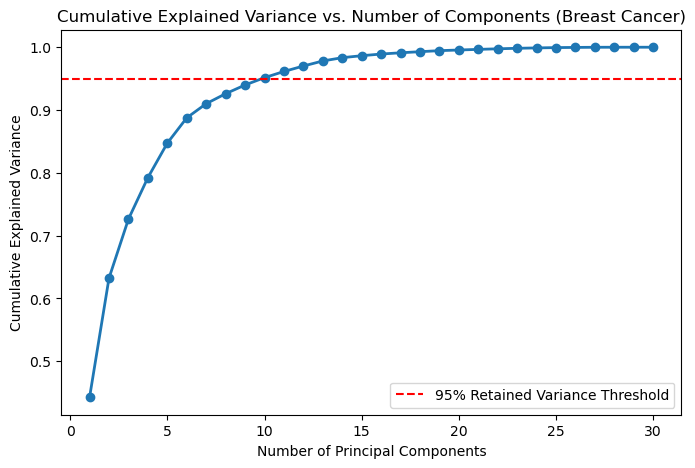

In [25]:

# Calculate cumulative sum of explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance against number of components
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Retained Variance Threshold')
plt.xlabel('Number of Principal Components') 
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Components (Breast Cancer)')
plt.legend()
plt.show()

### Interpretation

The curve contains $30$ points, corresponding to the 30 possible principal components. We look for the first point where the cumulative explained variance reaches **95%**. 
This  occurd at component $10$, PCA reduced the dimensionality from 30 original features to 10 principal components while preserving at least 95% of the variance

## Step 3: Choose the number of components that retains ~95% of the variance and justify it

In [26]:
# Choose the minimum number of components needed to reach >= 95% variance
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Fit PCA with the chosen number of components
pca_95 = PCA(n_components=n_95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print(X_pca_95.shape)

print("Variance kept per component:", pca_95.explained_variance_ratio_)
print("Total variance retained:", pca_95.explained_variance_ratio_.sum())
print(f"Number of components needed for ~95% variance: {n_95}")

(569, 10)
Variance kept per component: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]
Total variance retained: 0.9515688143366666
Number of components needed for ~95% variance: 10


### Interpretation 

- **Dimensionality after PCA:** (569, 10) 
- PCA reduced the dimensionality from 30 features to 10 components while retaining 95% of the variance.

## Step 4: Reduce the data to 2 components and produce a 2D scatter plot, coloring points by a known group if available

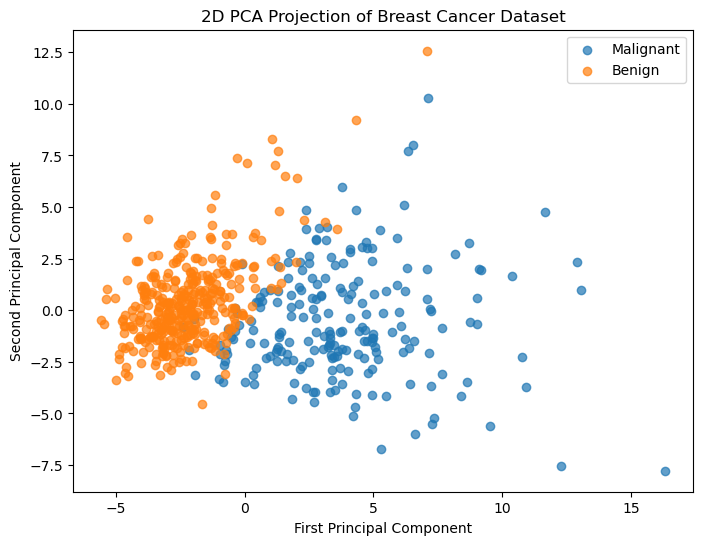

In [27]:
# Take my 30 original features and represent them using only 2 principal components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 2D Scatter plot colored by target diagnosis (Malignant vs Benign)
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2d[y == 0, 0],
    X_pca_2d[y == 0, 1],
    label='Malignant',
    alpha=0.7
)

plt.scatter(
    X_pca_2d[y == 1, 0],
    X_pca_2d[y == 1, 1],
    label='Benign',
    alpha=0.7
)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D PCA Projection of Breast Cancer Dataset')
plt.legend()
plt.show()

### Interpretation
There are two colors that represent two classes in this histogram. The orange represents benign, and as we can see, it is more dense than the other class, which is blue and represents malignant. Malignant appears to be more spread out and has more dispersion. However, there is an overlap between the two classes. There are points that overlap, meaning the PCA couldn't fully separate between the two classes.

------

## Step 5: Document what the reduction preserved and what it cost in Markdown.


PCA reduced the dataset from **30 original features to 10 principal components**, reducing the dimensionality while retaining approximately **95.16% of the total variance**.

The first principal component preserved the largest amount of variance (**44.27%**), followed by the second component (**18.97%**). The remaining components contributed smaller amounts of variance.

The main benefit of this reduction is that the dataset now has fewer dimensions, which can reduce computational complexity and make the data easier to work with while preserving most of its variance.

The cost of the reduction is that approximately **4.84% of the variance was lost**. In addition, the new principal components are combinations of the original features, so the resulting features are less directly interpretable than the original features.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="refs"></a>
# References


- High-dimensional data : https://www.sciencedirect.com/topics/computer-science/high-dimensional-data
-  Challenges of High-Dimensional Data: https://deepai.org/machine-learning-glossary-and-terms/high-dimensional-data
-  PCA Explained : https://www.youtube.com/watch?v=2NEu9dbM4A8